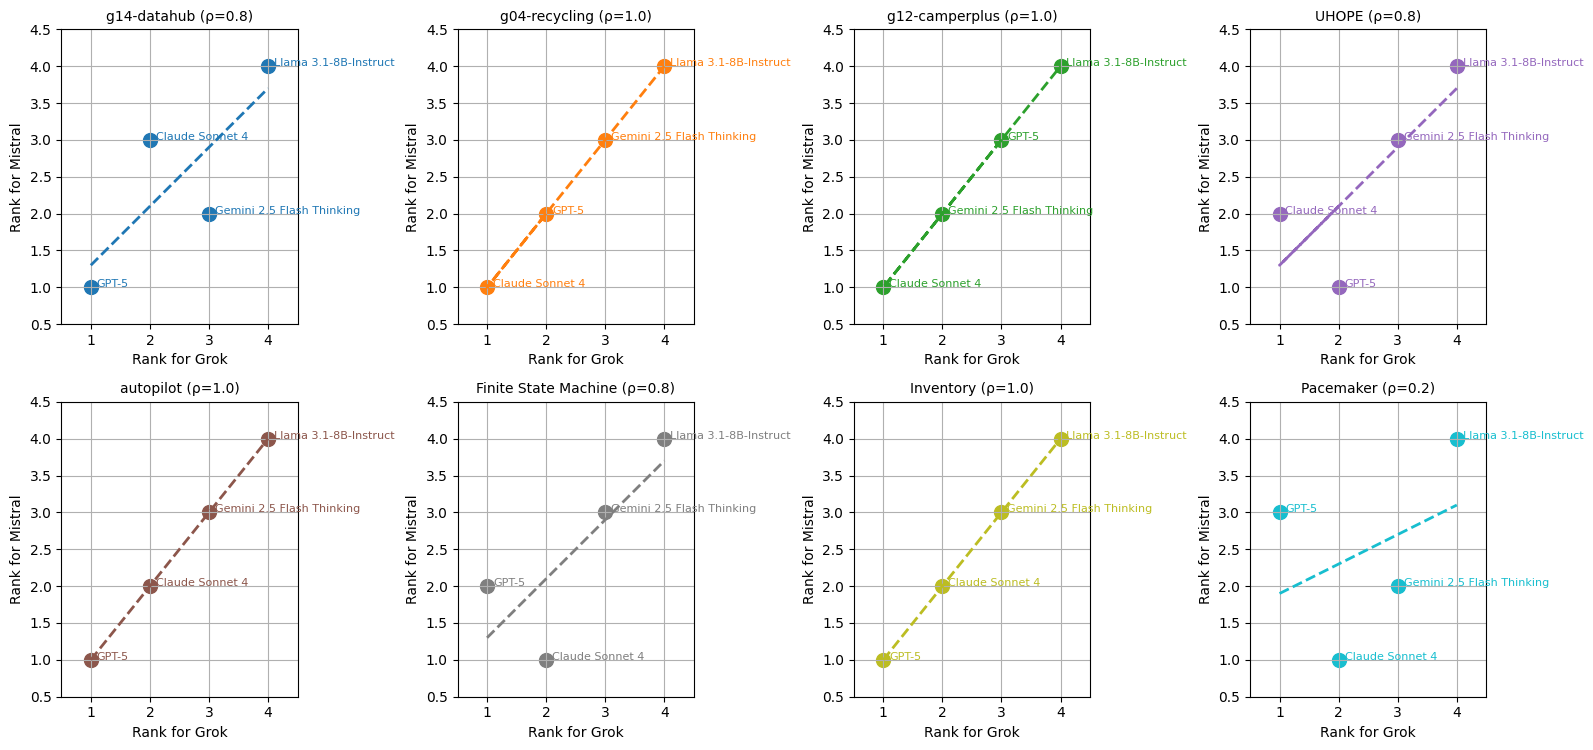

In [90]:
# Spearman Rank Correlation Plot for Model Rankings Across Datasets

import matplotlib.pyplot as plt
import numpy as np

# Data setup
projects = ["g14-datahub", "g04-recycling", "g12-camperplus", "UHOPE", 
            "autopilot", "Finite State Machine", "Inventory", "Pacemaker"]

project_titles = [
    "g14-datahub (ρ=0.8)", "g04-recycling (ρ=1.0)", "g12-camperplus (ρ=1.0)", 
    "UHOPE (ρ=0.8)", "autopilot (ρ=1.0)", "Finite State Machine (ρ=0.8)", 
    "Inventory (ρ=1.0)", "Pacemaker (ρ=0.2)"
]

models = ["GPT-5", "Claude Sonnet 4", "Gemini 2.5 Flash Thinking", "Llama 3.1-8B-Instruct"]

rank_for_G = {
    "g14-datahub": [1, 2, 3, 4],
    "g04-recycling": [2, 1, 3, 4],
    "g12-camperplus": [3, 1, 2, 4],
    "UHOPE": [2, 1, 3, 4],
    "autopilot": [1, 2, 3, 4],
    "Finite State Machine": [1, 2, 3, 4],
    "Inventory": [1, 2, 3, 4],
    "Pacemaker": [1, 2, 3, 4],
}

rank_for_M = {
    "g14-datahub": [1, 3, 2, 4],
    "g04-recycling": [2, 1, 3, 4],
    "g12-camperplus": [3, 1, 2, 4],
    "UHOPE": [1, 2, 3, 4],
    "autopilot": [1, 2, 3, 4],
    "Finite State Machine": [2, 1, 3, 4],
    "Inventory": [1, 2, 3, 4],
    "Pacemaker": [3, 1, 2, 4],
}

# Assign a unique color per project
project_colors = plt.cm.tab10(np.linspace(0, 1, len(projects)))

# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, project in enumerate(projects):
    ax = axes[i]
    x = np.array(rank_for_G[project])
    y = np.array(rank_for_M[project])
    color = project_colors[i]

    # Scatter points (same color for project)
    ax.scatter(x, y, color=color, s=100)

    # Annotate each model
    for j, model in enumerate(models):
        ax.text(x[j] + 0.1, y[j], model, fontsize=8, color=color)

    # Fit and plot trendline (same color as points)
    m, b = np.polyfit(x, y, 1)
    ax.plot(x, m * x + b, color=color, linestyle='--', linewidth=2, label=f"Trendline (ρ={project_titles[i].split('=')[-1][:-1]})")

    # Titles and labels
    ax.set_title(project_titles[i], fontsize=10)
    ax.set_xlabel("Rank for Grok")
    ax.set_ylabel("Rank for Mistral")
    ax.set_xlim(0.5, 4.5)
    ax.set_ylim(0.5, 4.5)
    ax.grid(True)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


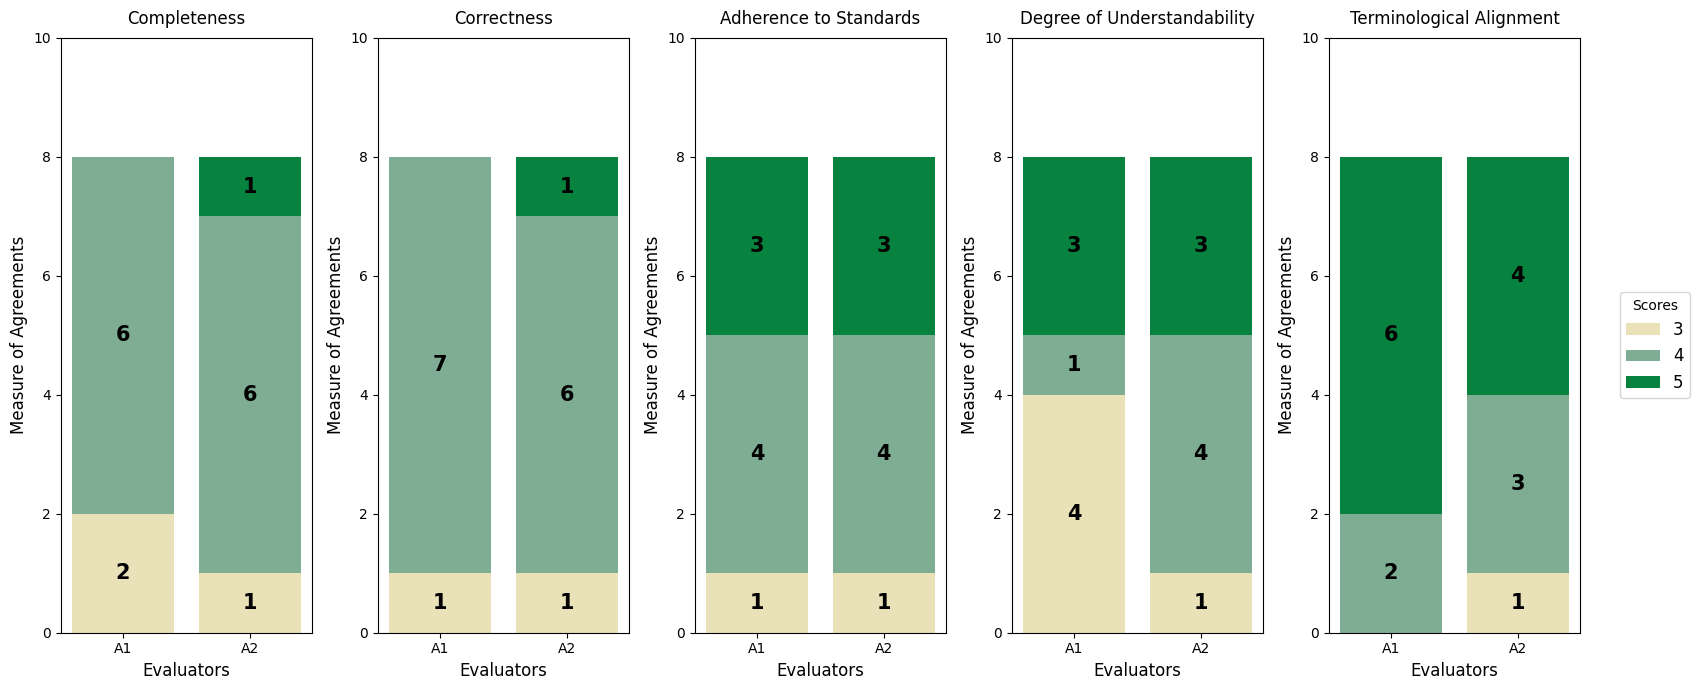

In [75]:
# Cohen Kappa Graph Plot for Evaluators Agreement Across Datasets

import matplotlib.pyplot as plt
import numpy as np

# Define evaluation criteria
criteria = [
    "Completeness",
    "Correctness",
    "Adherence to Standards",
    "Degree of Understandability",
    "Terminological Alignment"
]

# Data: Score → Measure of Agreement count per evaluator
data = {
    "Completeness": {
        "A1": {3: 2, 4: 6, 5: 0},
        "A2": {3: 1, 4: 6, 5: 1}
    },
    "Correctness": {
        "A1": {3: 1, 4: 7, 5: 0},
        "A2": {3: 1, 4: 6, 5: 1}
    },
    "Adherence to Standards": {
        "A1": {3: 1, 4: 4, 5: 3},
        "A2": {3: 1, 4: 4, 5: 3}
    },
    "Degree of Understandability": {
        "A1": {3: 4, 4: 1, 5: 3},
        "A2": {3: 1, 4: 4, 5: 3}
    },
    "Terminological Alignment": {
        "A1": {3: 0, 4: 2, 5: 6},
        "A2": {3: 1, 4: 3, 5: 4}
    }
}

# Create subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 7))
axes = axes.flatten()

colors = {3: "#E9E1B7", 4: "#21724594", 5: "#08823FFF"}
# different color for each score

for i, crit in enumerate(criteria):
    ax = axes[i]
    evals = ["A1", "A2"]
    bottoms = np.zeros(len(evals))  # start stacking from zero

    # Plot stacked bars for each score
    for score in sorted(colors.keys()):
        heights = [data[crit][ev][score] for ev in evals]
        bars = ax.bar(evals, heights, bottom=bottoms, label=f"Score {score}", color=colors[score])

        # Add labels inside each bar section
        for bar, h in zip(bars, heights):
            if h > 0:  # Only label non-zero sections
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + h / 2,
                    str(h),
                    ha='center', va='center',
                    fontsize=15, color='black', fontweight='bold'
                )

        bottoms += heights

    # Formatting
    ax.set_title(crit, fontsize=12, pad=10, loc='center')
    ax.set_ylabel("Measure of Agreements", fontsize=12)
    ax.set_xlabel("Evaluators", fontsize=12)
    ax.set_ylim(0, max(bottoms) + 2)

# Adjust layout
fig.legend([f"{s}" for s in colors.keys()], loc="center", ncol=1, fontsize=12, bbox_to_anchor=(0.83, 0.5), title="Scores")
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()


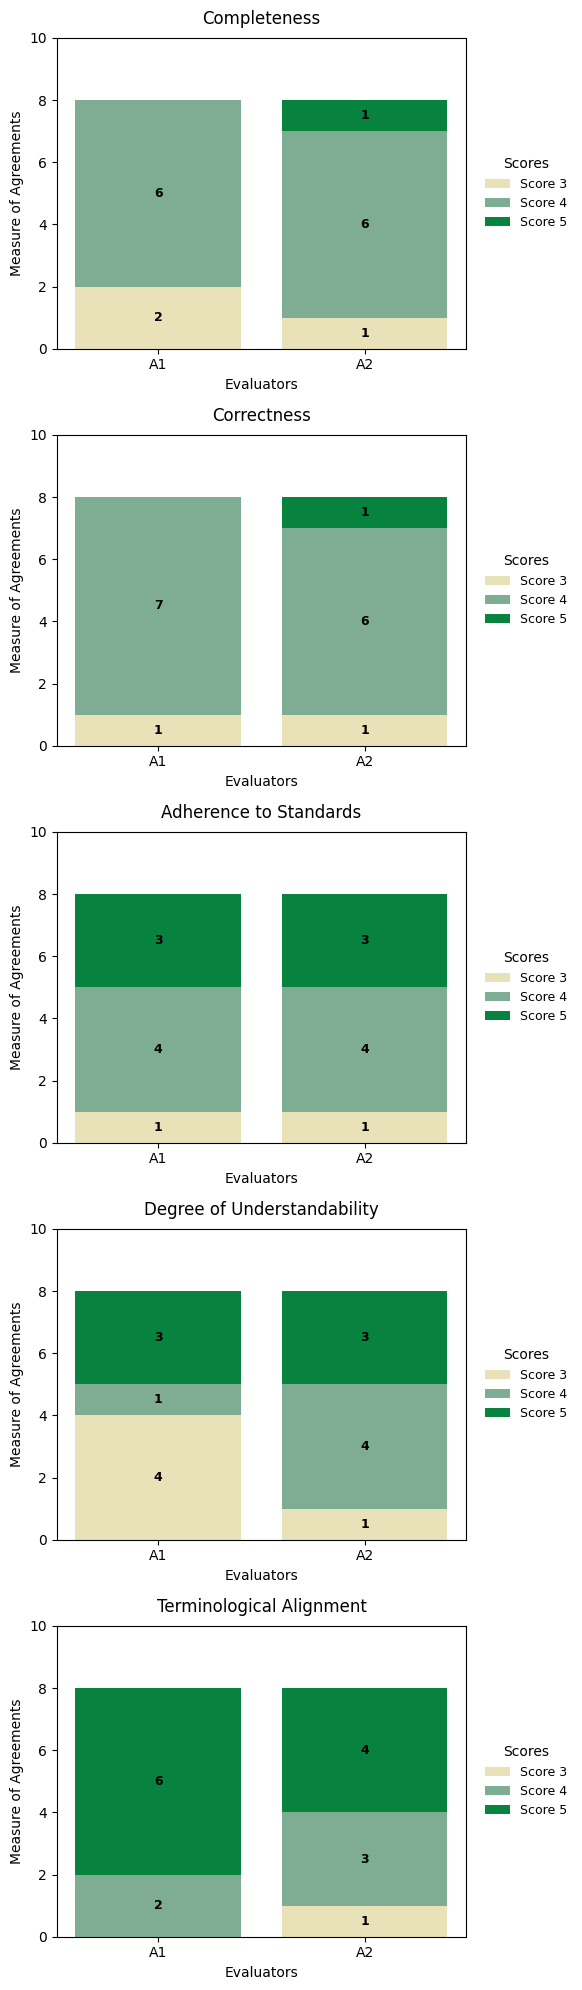

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Define evaluation criteria
criteria = [
    "Completeness",
    "Correctness",
    "Adherence to Standards",
    "Degree of Understandability",
    "Terminological Alignment"
]

# Data: Score → Measure of Agreement count per evaluator
data = {
    "Completeness": {
        "A1": {3: 2, 4: 6, 5: 0},
        "A2": {3: 1, 4: 6, 5: 1}
    },
    "Correctness": {
        "A1": {3: 1, 4: 7, 5: 0},
        "A2": {3: 1, 4: 6, 5: 1}
    },
    "Adherence to Standards": {
        "A1": {3: 1, 4: 4, 5: 3},
        "A2": {3: 1, 4: 4, 5: 3}
    },
    "Degree of Understandability": {
        "A1": {3: 4, 4: 1, 5: 3},
        "A2": {3: 1, 4: 4, 5: 3}
    },
    "Terminological Alignment": {
        "A1": {3: 0, 4: 2, 5: 6},
        "A2": {3: 1, 4: 3, 5: 4}
    }
}

# Distinct colors for each score
colors = {3: "#E9E1B7", 4: "#21724594", 5: "#08823FFF"}

# Create 5 vertically stacked subplots
fig, axes = plt.subplots(5, 1, figsize=(10, 20))
axes = axes.flatten()

for i, crit in enumerate(criteria):
    ax = axes[i]
    evals = ["A1", "A2"]
    bottoms = np.zeros(len(evals))  # Start stacking from zero

    # Plot stacked bars for each score
    for score in sorted(colors.keys()):
        heights = [data[crit][ev][score] for ev in evals]
        bars = ax.bar(evals, heights, bottom=bottoms, label=f"Score {score}", color=colors[score])

        # Add labels inside each bar section
        for bar, h in zip(bars, heights):
            if h > 0:  # Only label non-zero sections
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + h / 2,
                    str(h),
                    ha='center', va='center',
                    fontsize=9, color='black', fontweight='bold'
                )

        bottoms += heights

    # Formatting
    ax.set_title(crit, fontsize=12, pad=10, loc='center')
    ax.set_ylabel("Measure of Agreements", fontsize=10)
    ax.set_xlabel("Evaluators", fontsize=10)
    ax.set_ylim(0, max(bottoms) + 2)
    # ax.set_axisbelow(True)  # grid behind bars
    # Add legend beside each subplot
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        frameon=False,
        title="Scores"
    )

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.6, 1])
plt.show()


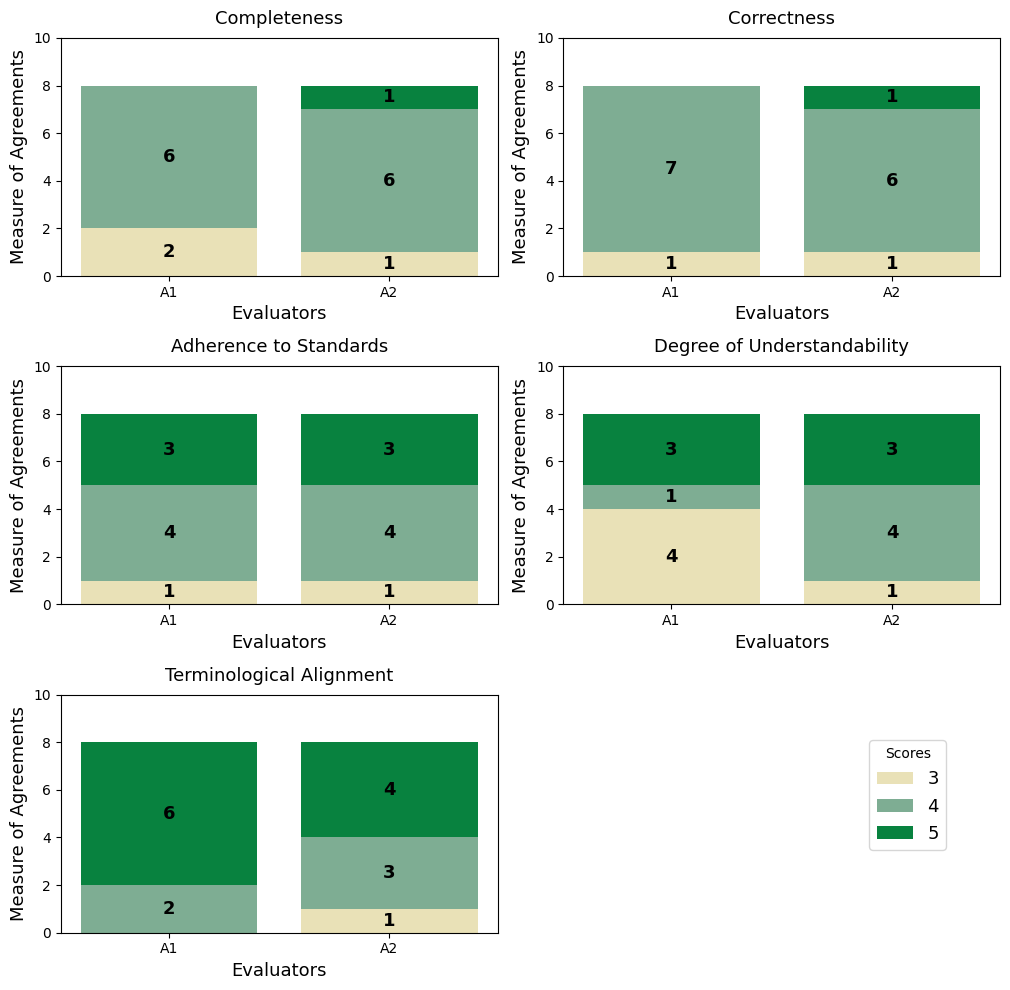

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Define evaluation criteria
criteria = [
    "Completeness",
    "Correctness",
    "Adherence to Standards",
    "Degree of Understandability",
    "Terminological Alignment"
]

# Data: Score → Measure of Agreement count per evaluator
data = {
    "Completeness": {
        "A1": {3: 2, 4: 6, 5: 0},
        "A2": {3: 1, 4: 6, 5: 1}
    },
    "Correctness": {
        "A1": {3: 1, 4: 7, 5: 0},
        "A2": {3: 1, 4: 6, 5: 1}
    },
    "Adherence to Standards": {
        "A1": {3: 1, 4: 4, 5: 3},
        "A2": {3: 1, 4: 4, 5: 3}
    },
    "Degree of Understandability": {
        "A1": {3: 4, 4: 1, 5: 3},
        "A2": {3: 1, 4: 4, 5: 3}
    },
    "Terminological Alignment": {
        "A1": {3: 0, 4: 2, 5: 6},
        "A2": {3: 1, 4: 3, 5: 4}
    }
}

# Create 3x2 subplots (6 total, but only 5 used)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

colors = {3: "#E9E1B7", 4: "#21724594", 5: "#08823FFF"}

for i, crit in enumerate(criteria):
    ax = axes[i]
    evals = ["A1", "A2"]
    bottoms = np.zeros(len(evals))

    # Plot stacked bars for each score
    for score in sorted(colors.keys()):
        heights = [data[crit][ev][score] for ev in evals]
        bars = ax.bar(evals, heights, bottom=bottoms, label=f"Score {score}", color=colors[score])

        # Add labels inside each stacked section
        for bar, h in zip(bars, heights):
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + h / 2,
                    str(h),
                    ha='center', va='center',
                    fontsize=13, color='black', fontweight='bold'
                )
        bottoms += heights

    # Titles and labels
    ax.set_title(crit, fontsize=13, pad=10, loc='center')
    ax.set_ylabel("Measure of Agreements", fontsize=13)
    ax.set_xlabel("Evaluators", fontsize=13)
    ax.set_ylim(0, max(bottoms) + 2)

# Hide unused subplot (6th one)
if len(criteria) < len(axes):
    axes[len(criteria)].axis('off')

# Add a shared legend
fig.legend(
    [f"{s}" for s in colors.keys()],
    loc="center right",
    fontsize=13,
    title="Scores",
    bbox_to_anchor=(0.8, 0.2)
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


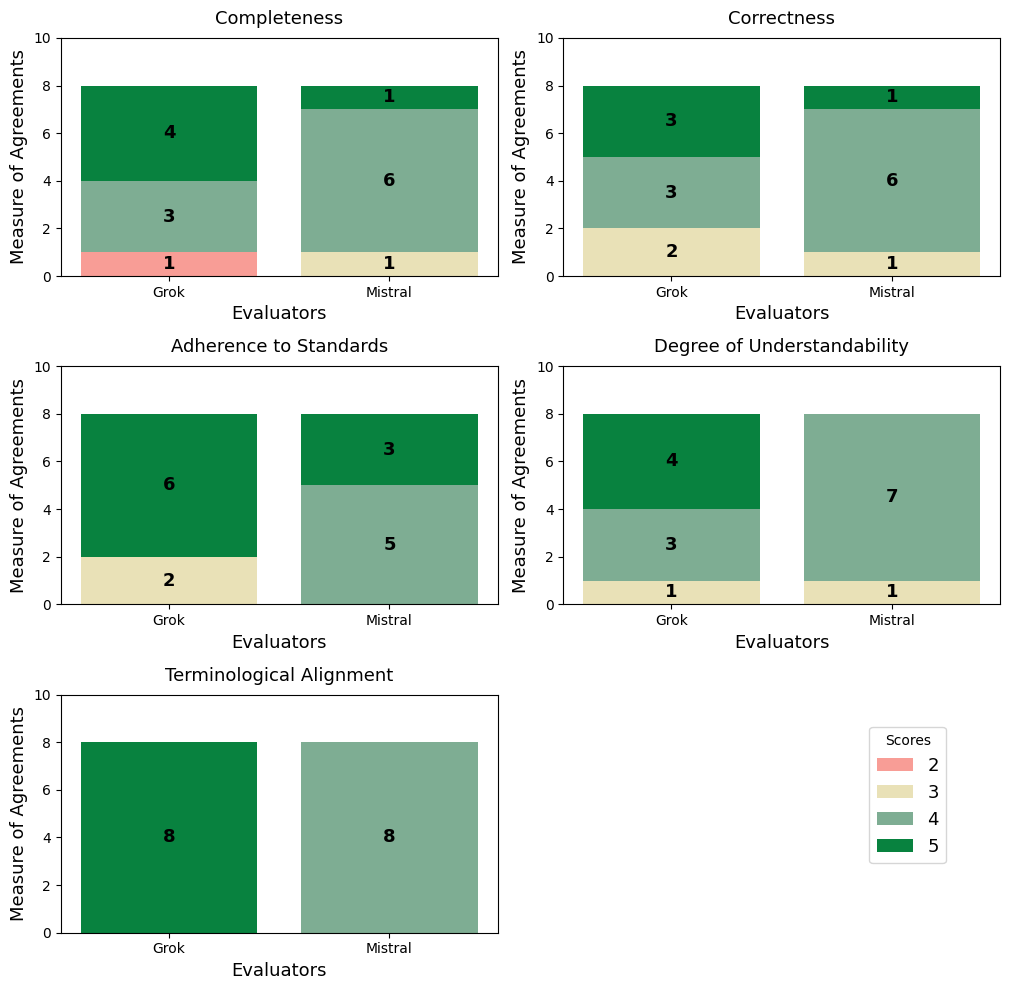

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Define evaluation criteria
criteria = [
    "Completeness",
    "Correctness",
    "Adherence to Standards",
    "Degree of Understandability",
    "Terminological Alignment"
]

# Data: Score → Measure of Agreement count per evaluator
data = {
    "Completeness": {
        "Grok": {2: 1, 3: 0, 4: 3, 5: 4},
        "Mistral": {2: 0, 3: 1, 4: 6, 5: 1}
    },
    "Correctness": {
        "Grok": {3: 2, 4: 3, 5: 3},
        "Mistral": {3: 1, 4: 6, 5: 1}
    },
    "Adherence to Standards": {
        "Grok": {3: 2, 5: 6},
        "Mistral": {4: 5, 5: 3}
    },
    "Degree of Understandability": {
        "Grok": {3: 1, 4: 3, 5: 4},
        "Mistral": {3: 1, 4: 7}
    },
    "Terminological Alignment": {
        "Grok": {5: 8},
        "Mistral": {4: 8}
    }
}

# Create 3x2 subplots (6 total, but only 5 used)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# Colors for scores
colors = {2: "#F88F87DE", 3: "#E9E1B7", 4: "#21724594", 5: "#08823FFF"}

for i, crit in enumerate(criteria):
    ax = axes[i]
    evals = ["Grok", "Mistral"]
    bottoms = np.zeros(len(evals))

    # Plot stacked bars for each score
    for score in sorted(colors.keys()):
        heights = [data[crit][ev].get(score, 0) for ev in evals]  # <-- fixed KeyError
        bars = ax.bar(evals, heights, bottom=bottoms, label=f"Score {score}", color=colors[score])

        # Add labels inside each stacked section
        for bar, h in zip(bars, heights):
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + h / 2,
                    str(h),
                    ha='center', va='center',
                    fontsize=13, fontweight='bold'
                )
        bottoms += heights

    # Titles and axes labels
    ax.set_title(crit, fontsize=13, pad=10, loc='center')
    ax.set_ylabel("Measure of Agreements", fontsize=13)
    ax.set_xlabel("Evaluators", fontsize=13)
    ax.set_ylim(0, max(bottoms) + 2)

# Hide unused subplot (6th one)
if len(criteria) < len(axes):
    axes[len(criteria)].axis('off')

# Shared legend
# handles = [plt.Rectangle((0,0),1,1, color=colors[s]) for s in sorted(colors.keys())]
labels = [f"{s}" for s in sorted(colors.keys())]
fig.legend(
    [f"{s}" for s in colors.keys()],
    loc="center right",
    fontsize=13,
    title="Scores",
    bbox_to_anchor=(0.8, 0.2)
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


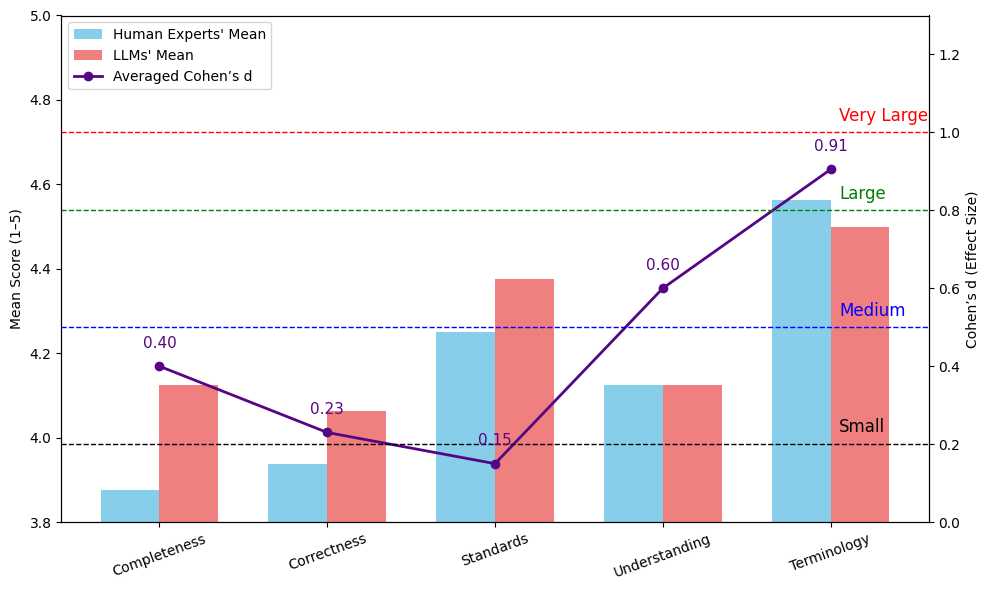

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# ----- Data -----
criteria = ["Completeness", "Correctness", "Standards", "Understanding", "Terminology"]
llm_means = [4.125, 4.062, 4.375, 4.125, 4.50]
human_means = [3.875, 3.938, 4.250, 4.125, 4.562]

# Original LLM and Human Cohen's d
llm_d = [0.30, 0.18, 0.30, 0.86, np.inf]
human_d = [0.50, 0.28, 0.00, 0.34, 0.61]

# Cap infinite values for plotting
llm_d_display = [min(d, 1.2) for d in llm_d]

# Calculate approximate overall Cohen's d per criterion
overall_d = [(l + h)/2 for l, h in zip(llm_d_display, human_d)]

x = np.arange(len(criteria))
width = 0.35

# ----- Figure setup -----
fig, ax1 = plt.subplots(figsize=(10,6))

# Bar chart for mean scores
bars1 = ax1.bar(x - width/2, human_means, width, label="Human Experts' Mean", color='skyblue')
bars2 = ax1.bar(x + width/2, llm_means, width, label="LLMs' Mean", color='lightcoral')

ax1.set_ylabel("Mean Score (1–5)")
ax1.set_ylim(3.8, 5)
ax1.set_xticks(x)
ax1.set_xticklabels(criteria, rotation=20)
# ax1.set_title("Human–LLM Alignment")

# ----- Second y-axis for overall Cohen's d -----
ax2 = ax1.twinx()
ax2.plot(x, overall_d, color='#540684', marker='o', linewidth=2, label="Averaged Cohen’s d")
ax2.set_ylabel("Cohen’s d (Effect Size)")
ax2.set_ylim(-0.0, 1.3)

# Threshold lines for interpretation
for level, color, label in [(0.2, 'black', 'Small'), (0.5, 'blue', 'Medium'), (0.8, 'green', 'Large'), (1.0, 'red', 'Very Large')]:
    ax2.axhline(level, color=color, linestyle='--', linewidth=1)
    ax2.text(len(criteria)-0.95, level+0.03, label, color=color, fontsize=12)

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# Annotate overall Cohen’s d values
for i, d in enumerate(overall_d):
    ax2.text(x[i], d + 0.04 if d >= 0 else d - 0.08, f"{d:.2f}", ha='center', va='bottom' if d >= 0 else 'top', fontsize=11, color='#540684')

plt.tight_layout()
plt.show()
